In [ ]:
import os
import numpy as np
from sklearn.cluster import SpectralClustering
import cvxpy as cp
import mosek

import utils

SAVE = False
PREFIX = './results/sem_neg'

# Check restuls dir exists and create
if not os.path.exists(PREFIX):
    os.makedirs(PREFIX)

## Load and plot data

Shape of: X: (122, 1214)  -  Y: (2, 1214)  -  data: (124, 1214)
(Min, Max) values of: X: (-7.201, 18.151)  - Y: (-1.731, 1.732)  -  data: (-7.201, 18.151)
Mean value of: X: 0.000  -  Y: -0.000  -  data: 0.000
Std value of: X: 1.000  -  Y: 1.000  -  data: 1.000


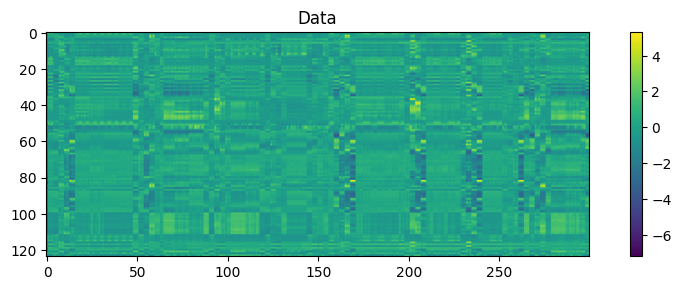

In [ ]:
Data = utils.load_accoustic_data(all_data=True)
N, M = Data.shape

lamb0 = np.sqrt(np.log(N)/M)
print('lamb0:', lamb0)

## Undirected SEM

In [ ]:
# Estimate A
lamb0 = np.sqrt(np.log(N)/M)

# Mults = np.array( [159.78, 264.05, 368.32, 472.59] ) / lamb0
Mults = np.array( [159.78, 300, 360, 472.59] ) / lamb0


A_undir_sem = []
for mult in Mults:
    lamb = mult*lamb0

    A = cp.Variable((N,N), symmetric=True)
    obj = cp.sum_squares(A@Data - Data) + lamb*cp.sum(cp.abs(A))
    constr = [ cp.abs( A[np.eye(N, dtype=bool)] ) <= 1e-6]

    prob = cp.Problem(cp.Minimize(obj), constr)
    prob.solve(solver='MOSEK', verbose=False)

    print(f'Lamb (mult): {lamb:.4f} ({mult})  - status: {prob.status}')

    A_est = A.value

    A_undir_sem.append(A_est)
    


Lamb (mult): 159.7800 (2535.6864888262235)  - status: optimal
Lamb (mult): 300.0000 (4760.958484465309)  - status: optimal
Lamb (mult): 360.0000 (5713.150181358371)  - status: optimal
Lamb (mult): 472.5900 (7499.9379005782)  - status: optimal


In [ ]:
# # LOAD DATA
# lamb0s = [159.78]
# A_undir_sem = []
# Mults = [1]*len(lamb0s)
# for lamb0 in lamb0s:
#     file_name = PREFIX + f'/sem_und_{lamb0}.npy'
#     A_undir_sem.append(np.load(file_name, allow_pickle=True))
# A_undir_sem = [np.load(file_name, allow_pickle=True)]


### Plot graph and adjacency

- Lambda: 159.7800  -  Edge density above threshold: 0.055  -  Output edges: 13
	Saved as: ./results/sem_neg_unc/sem_und_unc_159.78


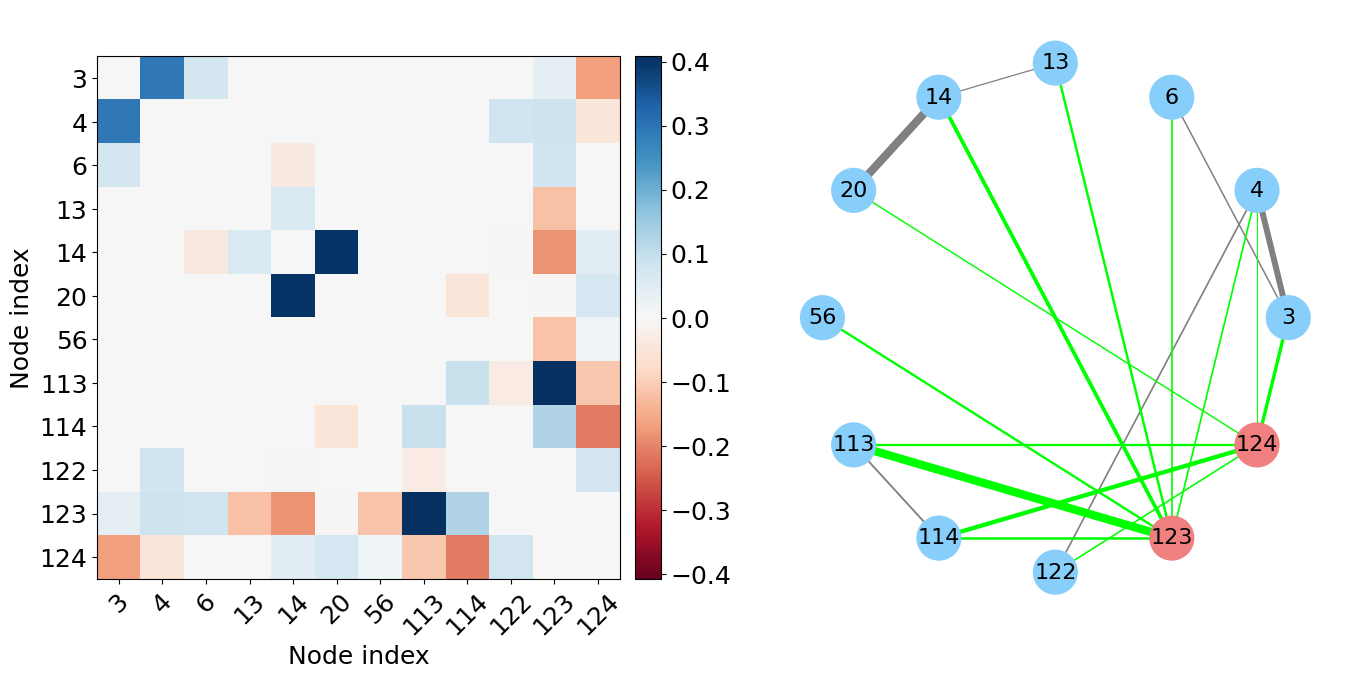

In [ ]:
# Plot A
th = 0.05
for i, A_est in enumerate(A_undir_sem):
    mult = Mults[i] * lamb0
    file_name = f'{PREFIX}/sem_und_unc_{mult}'
    # utils.save_plot_graph(A_est, th, mult, max_width=4, file_name=file_name, save=SAVE)
    utils.save_plot_subgraph(A_est, th, mult, save=SAVE, max_width=6, file_name=file_name)
    utils.sort_edges_by_weight(A_est, th, output_file=file_name, abs_val=True, save=SAVE)

### Plot for different thresholds

In [5]:
# Plot A - Grid for thresholds
thresholds = [0, 1e-3, 0.01, 0.05, 0.1]

# Ensure lambdas are available. If not defined in previous cells (e.g. if loaded from file), define them
# Assuming lamb0 and Mults might be needed, but usually A_undir_sem is a list aligned with Mults
# Let's try to get lambdas if possible, or just iterate

if 'Mults' in locals() and 'lamb0' in locals():
    lambdas = Mults * lamb0
else:
    # Fallback or assume defined
    # For safety in this script we don't define them here as they depend on data loaded in previous cells
    pass

for i, A_est in enumerate(A_undir_sem):
    # Try to get lambda value for title
    try:
        lamb = lambdas[i]
    except:
        lamb = 0 # Default if not found

    print(f'Plotting grid for Lambda idx {i}: {lamb:.4f}')
    
    # Use the new grid function
    utils.save_plot_subgraph_grid(A_est, thresholds, lamb, 
                                  file_name=f'{PREFIX}/sem_und_grid_{i}', save=True)


## Without connection of outputs variables

In [6]:
PREFIX = './results/sem_neg_unc'

In [ ]:

# Estimate A
lamb0 = np.sqrt(np.log(N)/M)

# Mults = np.array( [159.78, 280, 300, 320, 360, 472.59] ) / lamb0
Mults = np.array( [159.78, 300, 360, 472.59] ) / lamb0
A_undir_sem = []
for mult in Mults:
    lamb = mult*lamb0

    A = cp.Variable((N,N), symmetric=True)
    obj = cp.sum_squares(A@Data - Data) + lamb*cp.sum(cp.abs(A))
    constr = [ cp.abs( A[np.eye(N, dtype=bool)] ) <= 1e-6,
                cp.abs( A[-1,-2] ) <= 1e-6]
    
    prob = cp.Problem(cp.Minimize(obj), constr)
    prob.solve(solver='MOSEK', verbose=False)

    print(f'Lamb (mult): {lamb:.4f} ({mult})  - status: {prob.status}')

    A_est = A.value

    A_undir_sem.append(A_est)
    


Lamb (mult): 159.7800 (2535.6864888262235)  - status: optimal
Lamb (mult): 280.0000 (4443.561252167621)  - status: optimal
Lamb (mult): 300.0000 (4760.958484465309)  - status: optimal
Lamb (mult): 320.0000 (5078.355716762996)  - status: optimal
Lamb (mult): 360.0000 (5713.150181358371)  - status: optimal
Lamb (mult): 472.5900 (7499.9379005782)  - status: optimal


In [ ]:
# # LOAD DATA
# lamb0s = [159.78]
# A_undir_sem = []
# Mults = [1]*len(lamb0s)
# for lamb0 in lamb0s:
#     file_name = PREFIX + f'/sem_und_unc_{lamb0}.npy'
#     A_undir_sem.append(np.load(file_name, allow_pickle=True))
# A_undir_sem = [np.load(file_name, allow_pickle=True)]

### Plot graph and adjacency

- Lambda: 159.7800  -  Edge density above threshold: 0.055  -  Output edges: 13
	Saved as: ./results/sem_neg_unc/sem_und_unc_159.78


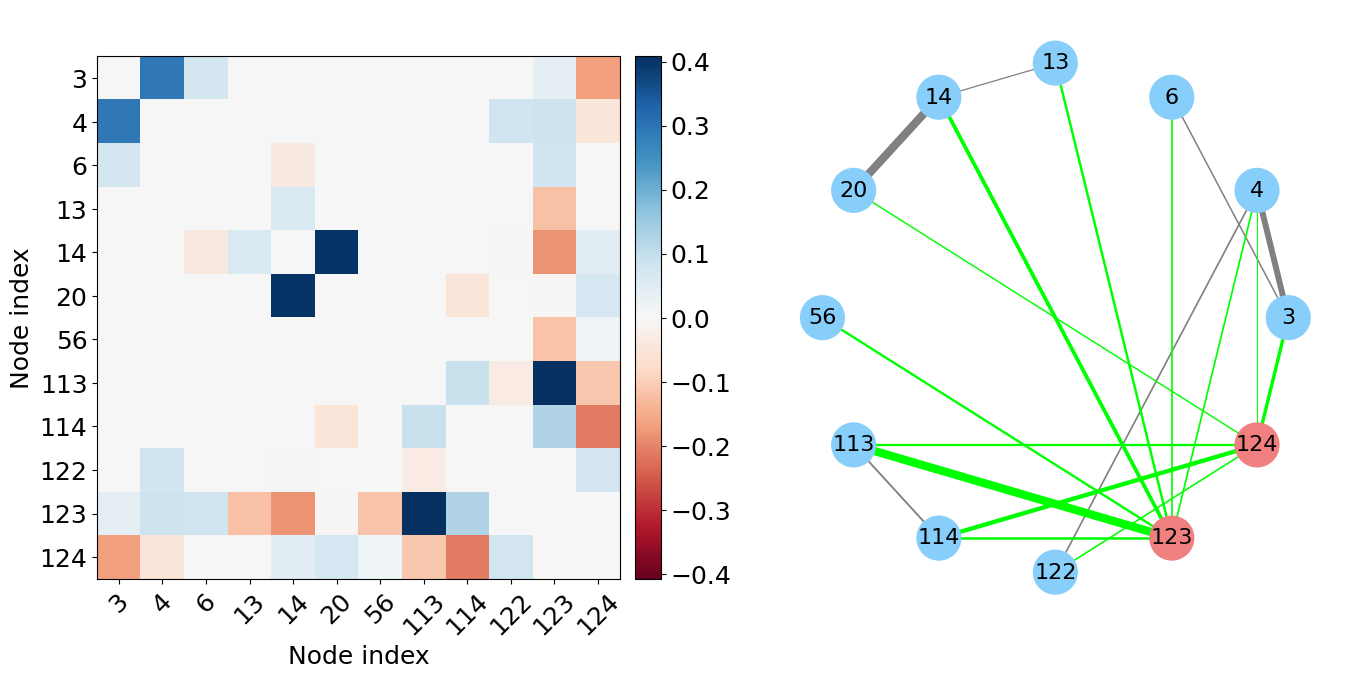

In [8]:
# Plot A
th = 0.05
for i, A_est in enumerate(A_undir_sem):
    mult = Mults[i] * lamb0
    file_name = f'{PREFIX}/sem_und_unc_{mult}'
    # utils.save_plot_graph(A_est, th, mult, max_width=4, file_name=file_name, save=SAVE)
    utils.save_plot_subgraph(A_est, th, mult, save=SAVE, max_width=6, file_name=file_name)
    utils.sort_edges_by_weight(A_est, th, output_file=file_name, abs_val=True, save=SAVE)

### Plot for different thresholds

In [ ]:
# Plot A - Grid for thresholds
thresholds = [0, 1e-3, 0.01, 0.05, 0.1]

# Ensure lambdas are available. If not defined in previous cells (e.g. if loaded from file), define them
# Assuming lamb0 and Mults might be needed, but usually A_undir_sem is a list aligned with Mults
# Let's try to get lambdas if possible, or just iterate

if 'Mults' in locals() and 'lamb0' in locals():
    lambdas = Mults * lamb0
else:
    # Fallback or assume defined
    # For safety in this script we don't define them here as they depend on data loaded in previous cells
    pass

for i, A_est in enumerate(A_undir_sem):
    # Try to get lambda value for title
    try:
        lamb = lambdas[i]
    except:
        lamb = 0 # Default if not found

    print(f'Plotting grid for Lambda idx {i}: {lamb:.4f}')
    
    # Use the new grid function
    utils.save_plot_subgraph_grid(A_est, thresholds, lamb, 
                                  file_name=f'{PREFIX}/sem_und_grid_{i}', save=True)


## Directed SEM

In [13]:
# Estimate A
lamb0 = np.sqrt(np.log(N)/M)

Mults = [0, 1e3, 1500, 2.5e3, 5e3] #[0, 25, 250, 500, 700, 800, 1e3]
Dir_sem = []
for mult in Mults:
    lamb = mult*lamb0

    A = cp.Variable((N,N), symmetric=False)
    obj = cp.sum_squares(A@Data - Data) + lamb*cp.sum(cp.abs(A))
    constr = [A[np.eye(N, dtype=bool)] == 0]

    prob = cp.Problem(cp.Minimize(obj), constr)
    prob.solve(solver='MOSEK', verbose=False)

    print(f'Lamb (mult): {lamb:.4f} ({mult})  - status: {prob.status}')
    
    A_est = A.value
    # A_est /= np.max(np.abs(A_est))

    Dir_sem.append(A_est)

Lamb (mult): 0.0000 (0)  - status: optimal
Lamb (mult): 63.0125 (1000.0)  - status: optimal
Lamb (mult): 94.5188 (1500)  - status: optimal
Lamb (mult): 157.5313 (2500.0)  - status: optimal
Lamb (mult): 315.0626 (5000.0)  - status: optimal


### Threshold = 0.05

- Lambda: 0.0000  -  Edge density above threshold: 0.816  -  Output edges: 230
- Lambda: 63.0125  -  Edge density above threshold: 0.145  -  Output edges: 47
- Lambda: 94.5188  -  Edge density above threshold: 0.117  -  Output edges: 34
- Lambda: 157.5313  -  Edge density above threshold: 0.086  -  Output edges: 22
- Lambda: 315.0626  -  Edge density above threshold: 0.053  -  Output edges: 13


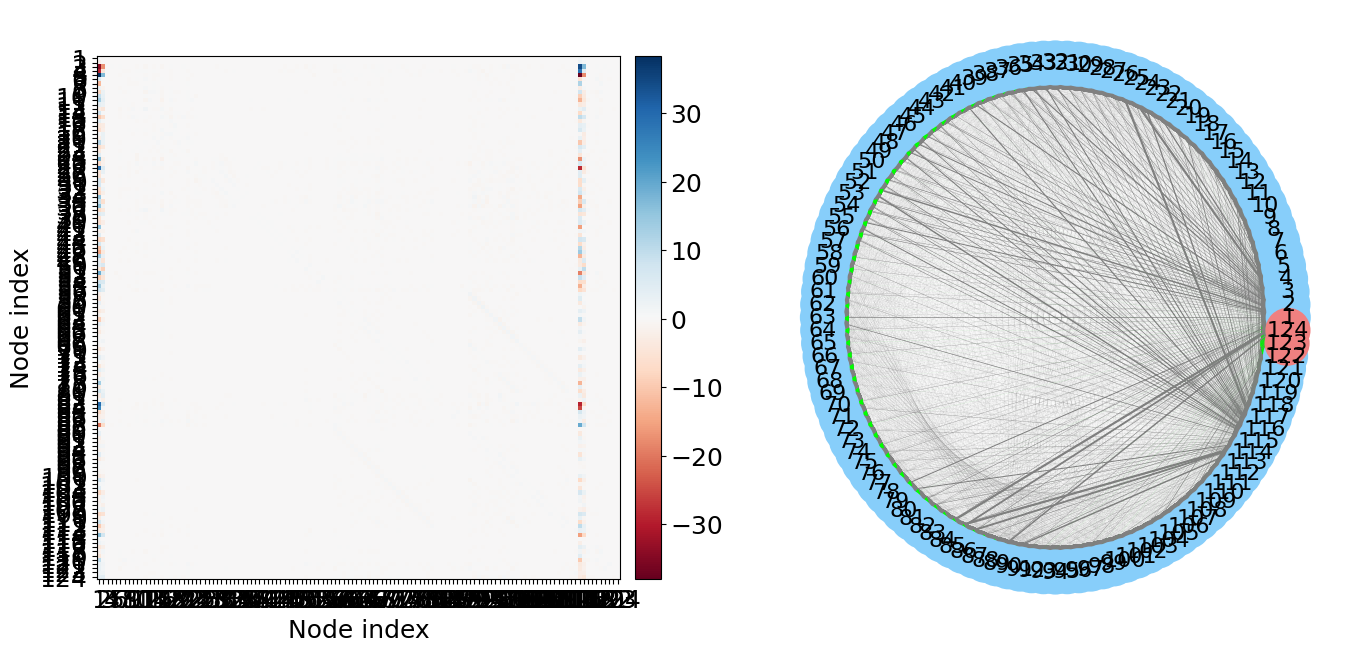

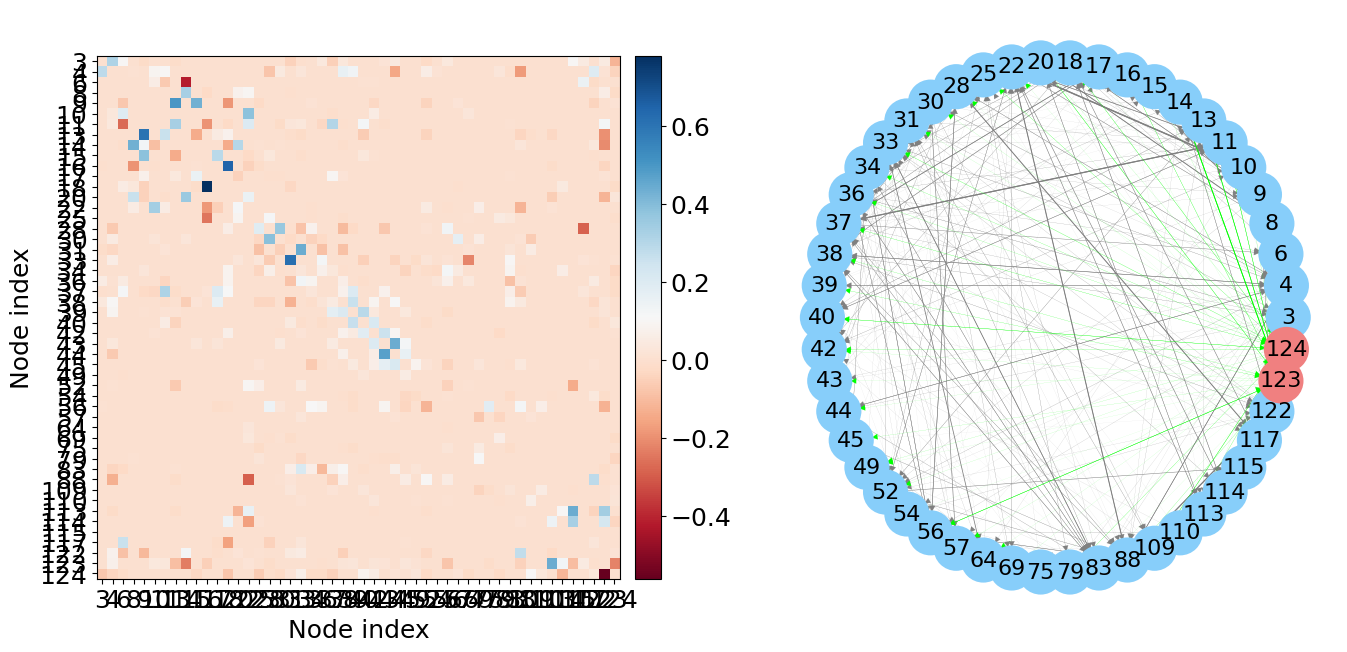

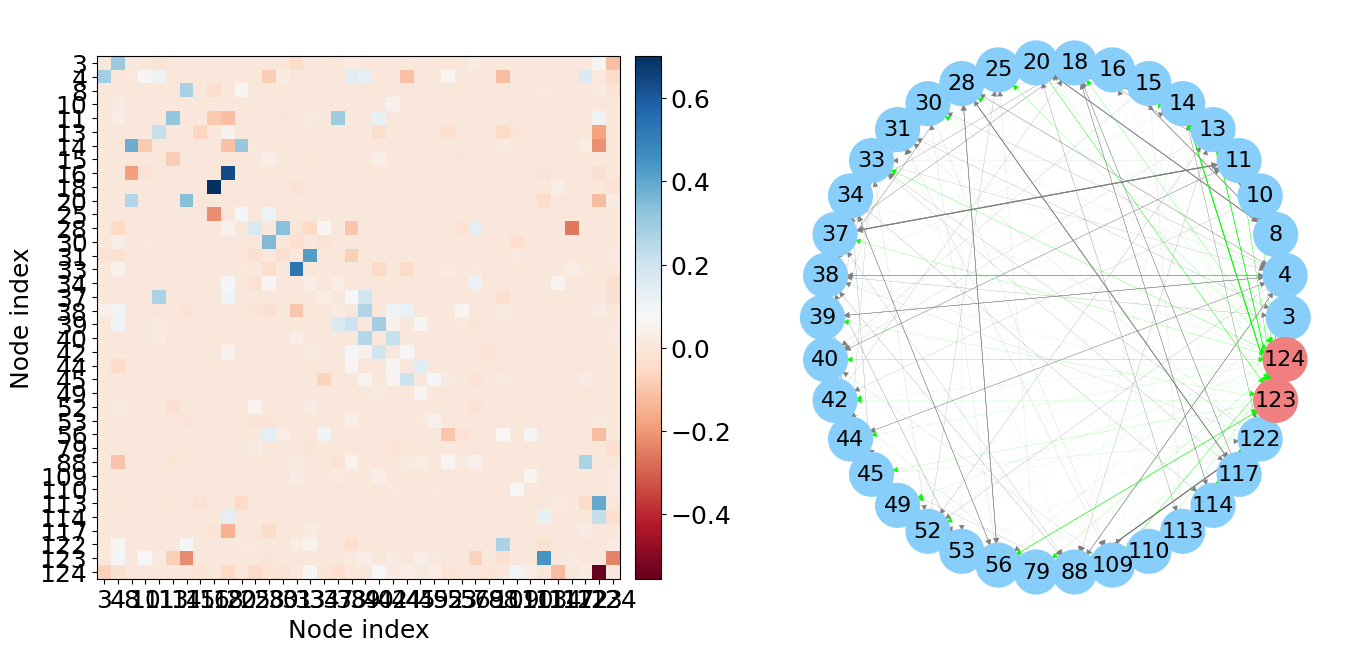

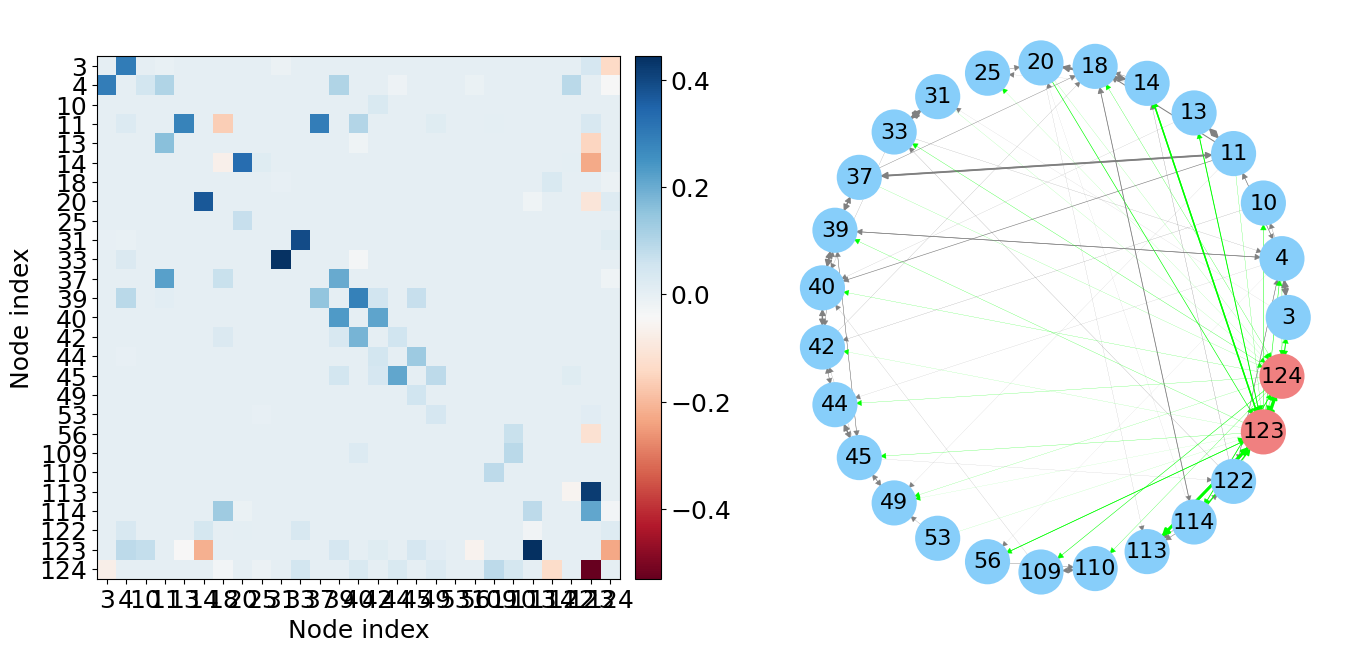

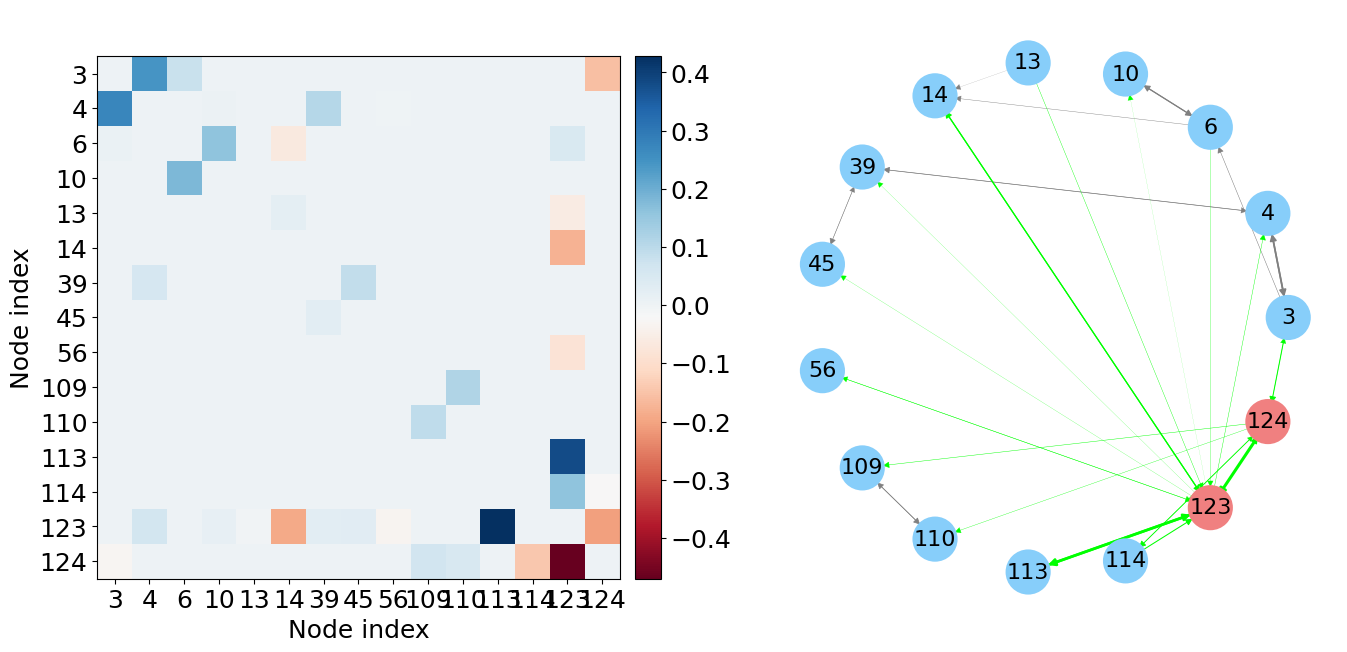

In [14]:
# Plot A

SAVE = False

th = 0.01
for i, A_est in enumerate(Dir_sem):
    mult = Mults[i]
    file_name = f'{PREFIX}/sem_dir{mult}_{th}'
    # utils.save_plot_graph(A_est, th, mult*lamb0, file_name=file_name, save=SAVE, directed=True)
    utils.save_plot_subgraph(A_est, th, mult*lamb0, file_name=file_name, save=SAVE, directed=True)